# 07-4. 기사별 요약과 재검색 루프가 있는 Tavily 뉴스 에이전트

이 실습은 07-3의 검증·재검색 구조에 **기사별 요약 노드**를 추가한 확장 예제이다.

## 학습 목표

1. Tavily 검색 결과를 기사별 요약으로 변환한다.
2. 요약 결과를 기준으로 검색 품질을 검증한다.
3. 결과가 부족하면 검색어를 재작성하고 다시 검색한다.
4. 최종 리포트에는 기사별 요약과 출처 URL을 함께 포함한다.
5. `stream()`으로 노드별 업데이트 데이터만 확인한다.

## 전체 흐름

```text
START
  ↓
검색
  ↓
요약
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

이 단계는 검색 결과를 바로 리포트로 만들지 않고, 먼저 기사별 요약을 생성한 뒤 검증한다.  
따라서 07-3보다 처리 과정은 길지만, 최종 리포트의 근거가 더 명확해진다.

## 0. 설치 패키지

이 실습은 `langchain-tavily` 패키지를 사용한다.  
기존 `langchain_community.tools.tavily_search.TavilySearchResults`는 사용하지 않는다.

```bash
uv add langgraph langchain-openai langchain-tavily python-dotenv grandalf
```

`.env` 파일에는 다음 API Key를 설정한다.

```text
OPENAI_API_KEY=sk-...
TAVILY_API_KEY=tvly-...
```

`grandalf`는 ASCII 그래프 시각화에 필요할 수 있다.

In [15]:
# 공통 환경 설정
import os
from datetime import datetime
from typing_extensions import TypedDict

from dotenv import load_dotenv
from IPython.display import Image, display

from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

from langgraph.graph import StateGraph, START, END

# .env 파일에서 API Key를 불러온다.
load_dotenv(override=True, dotenv_path="../.env")

# API Key가 없을 때 원인을 바로 알 수 있도록 명확한 오류를 발생시킨다.
if not os.getenv("OPENAI_API_KEY"):
    raise ValueError("OPENAI_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

if not os.getenv("TAVILY_API_KEY"):
    raise ValueError("TAVILY_API_KEY가 설정되어 있지 않다. ../.env 파일을 확인한다.")

# 최신 뉴스 검색과 리포트 작성에 사용할 현재 날짜이다.
TODAY = datetime.now().strftime("%Y-%m-%d")

# LLM은 요약, 검색어 재작성, 리포트 작성에 사용한다.
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# Tavily Search 도구를 초기화한다.
# topic="news"는 뉴스 검색에 맞춘 범주이다.
# time_range="month"는 최근 1개월 자료를 우선 검색하도록 한다.
tavily_tool = TavilySearch(
    max_results=5,
    topic="news",
    search_depth="advanced",
    time_range="month",
)

print("준비 완료")
print("오늘 날짜:", TODAY)

준비 완료
오늘 날짜: 2026-05-27


## 1. Tavily 검색 결과 정리 함수

`TavilySearch`는 보통 딕셔너리 형태의 결과를 반환한다.

```python
{
    "query": "검색어",
    "results": [
        {
            "title": "문서 제목",
            "url": "https://...",
            "content": "본문 일부",
            "score": 0.98
        }
    ]
}
```

그래프 노드에서는 실제 기사 목록만 필요하므로 `results` 필드만 추출한다.

In [16]:
def normalize_tavily_results(raw_result) -> list[dict]:
    """Tavily 반환값에서 실제 검색 결과 리스트만 추출한다.

    최신 TavilySearch는 {"results": [...]} 형태를 주로 반환한다.
    수업 환경 차이를 고려해 리스트가 바로 들어오는 경우도 함께 처리한다.
    """
    if isinstance(raw_result, dict):
        return raw_result.get("results", [])

    if isinstance(raw_result, list):
        return raw_result

    return []


def show_graph(app) -> None:
    """LangGraph 구조를 시각화한다.

    Mermaid PNG 생성이 실패하면 ASCII 그래프로 대체한다.
    """
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        print(f"Mermaid 이미지 생성 실패: {e}")
        print(app.get_graph().draw_ascii())

## 2. State 정의

`State`는 그래프 실행 중 유지되는 공유 상태 객체이다.  
각 노드는 현재 State를 입력받고, 변경할 값만 딕셔너리로 반환한다.

이번 실습에서는 검색 결과뿐 아니라 기사별 요약 결과도 State에 저장한다.

In [17]:
MAX_SEARCH_COUNT = 3  # 최초 검색 1회 + 재검색 최대 2회

class SummaryNewsState(TypedDict):
    topic: str                    # 사용자가 입력한 원래 주제
    search_query: str             # Tavily에 전달할 실제 검색어
    search_results: list[dict]    # Tavily 검색 원본 결과
    summaries: list[dict]         # 기사별 요약 결과
    is_sufficient: bool           # 검증 통과 여부
    feedback: str                 # 검증 결과 또는 개선 피드백
    report: str                   # 최종 리포트
    search_count: int             # 검색 실행 횟수


print("State 필드")
for field in SummaryNewsState.__annotations__:
    print("-", field)

State 필드
- topic
- search_query
- search_results
- summaries
- is_sufficient
- feedback
- report
- search_count


## 3. 검색 노드 만들기

검색 노드는 Tavily Search API를 호출한다.  
검색 결과는 `search_results`에 저장하고, 검색 횟수는 `search_count`에 저장한다.

In [18]:
def search_node(state: SummaryNewsState) -> dict:
    """Tavily Search API로 뉴스 검색을 수행한다."""

    # search_query가 비어 있으면 원래 topic을 검색어로 사용한다.
    query = state.get("search_query") or state["topic"]

    # 검색 횟수를 증가시켜 재검색 루프의 안전장치로 사용한다.
    search_count = state.get("search_count", 0) + 1

    print(f"  [검색 #{search_count}] 검색어: {query}")

    # TavilySearch는 {"query": "..."} 형태로 호출한다.
    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    print(f"  [검색] {len(results)}개 문서 수집")

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }

## 4. 요약 노드 만들기

요약 노드는 검색 결과를 기사별 요약으로 변환한다.  
이 노드를 분리하면 최종 리포트를 만들기 전에 각 기사의 핵심 내용을 먼저 정리할 수 있다.

In [19]:
summary_prompt = ChatPromptTemplate.from_messages([
    ("system", """뉴스 기사를 한국어로 2~3문장 요약한다.

규칙:
- 기사에 있는 정보만 사용한다.
- 날짜가 제공된 경우에만 날짜를 포함한다.
- 날짜, 수치, 기관명, 제품명은 추정하지 않는다.
- 원문에 없는 해석이나 과장된 표현을 추가하지 않는다."""),
    ("human", """제목: {title}
URL: {url}

내용:
{content}""")
])

summary_chain = summary_prompt | llm | StrOutputParser()


def summarize_node(state: SummaryNewsState) -> dict:
    """검색 결과를 기사별 요약으로 변환한다."""

    results = state.get("search_results", [])
    summaries: list[dict] = []

    print(f"  [요약] {len(results)}개 문서 요약 시작")

    for result in results:
        title = result.get("title", "제목 없음")
        url = result.get("url", "")
        content = result.get("content", "")

        # content가 없으면 LLM이 근거 없는 요약을 만들 수 있으므로 건너뛴다.
        if not content.strip():
            continue

        summary = summary_chain.invoke({
            "title": title,
            "url": url,
            "content": content[:1200],  # 비용과 속도를 고려해 일부 내용만 사용한다.
        })

        summaries.append({
            "title": title,
            "url": url,
            "summary": summary,
        })

        print(f"    - 요약 완료: {title[:50]}")

    return {"summaries": summaries}

## 5. 검증 노드 만들기

검증 노드는 기사별 요약 결과가 충분한지 판단한다.  
여기서는 초보자 실습에 맞게 다음 기준만 사용한다.

1. URL이 있는 요약인가?
2. 요약 길이가 너무 짧지 않은가?
3. 유효 요약이 3개 이상인가?

In [20]:
def verify_node(state: SummaryNewsState) -> dict:
    """요약 결과가 최종 리포트 작성에 충분한지 검증한다."""

    summaries = state.get("summaries", [])

    valid_summaries = [
        item for item in summaries
        if item.get("url") and len(item.get("summary", "")) >= 50
    ]

    is_sufficient = len(valid_summaries) >= 3

    if is_sufficient:
        feedback = "유효한 기사 요약이 3개 이상이다."
    else:
        feedback = (
            f"유효한 기사 요약이 {len(valid_summaries)}개이다. "
            "출처 URL이 있고 요약 길이가 충분한 뉴스가 더 필요하다."
        )

    print(f"  [검증] 유효 요약 {len(valid_summaries)}개 → 충분 여부: {is_sufficient}")

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }

## 6. 검색어 재작성 노드 만들기

검증 결과가 부족하면 같은 검색어로 반복하지 않는다.  
LLM을 사용해 더 구체적인 검색어를 만들고 다시 검색 노드로 이동한다.

In [21]:
rewrite_prompt = ChatPromptTemplate.from_messages([
    ("system", """검색 결과가 부족할 때 사용할 새 검색어를 작성한다.

규칙:
- 검색어 한 줄만 출력한다.
- 따옴표, 번호, 설명 문장을 붙이지 않는다.
- 오늘 날짜는 {today}이다.
- 최신 뉴스 검색에 적합하도록 최근성 표현을 포함한다.
- 이전 검색어와 너무 비슷하게 작성하지 않는다."""),
    ("human", """원래 주제: {topic}
이전 검색어: {search_query}
검증 피드백: {feedback}

새 검색어:""")
])

rewrite_chain = rewrite_prompt | llm | StrOutputParser()


def rewrite_query_node(state: SummaryNewsState) -> dict:
    """검증 실패 시 검색어를 재작성한다."""

    new_query = rewrite_chain.invoke({
        "today": TODAY,
        "topic": state["topic"],
        "search_query": state.get("search_query", ""),
        "feedback": state.get("feedback", ""),
    }).strip()

    # LLM이 빈 문자열을 반환하면 기본 검색어를 사용한다.
    if not new_query:
        new_query = f"{state['topic']} 최신 뉴스 최근 발표"

    print(f"  [검색어재작성] {new_query}")

    return {"search_query": new_query}

## 7. 리포트 작성 노드 만들기

리포트 작성 노드는 기사별 요약을 모아 최종 뉴스 브리핑을 생성한다.  
출처 URL을 반드시 포함해 검색 기반 응답의 근거를 확인할 수 있게 한다.

In [22]:
report_prompt = ChatPromptTemplate.from_messages([
    ("system", """뉴스 요약을 바탕으로 구조화된 브리핑 리포트를 작성한다.

규칙:
- 한국어로 작성한다.
- 출처 URL을 기사별로 반드시 포함한다.
- 검색 결과가 부족하면 부족하다는 점을 명시한다.
- 원문에 없는 날짜, 수치, 기관명을 만들지 않는다.
- 마크다운 형식으로 작성한다.

출력 형식:

## 뉴스 브리핑: {topic}

### 검색 개요
- 검색어:
- 검색 횟수:
- 기사 요약 수:
- 검증 결과:

### 주요 내용
2~3개 문장으로 요약한다.

### 기사별 요약
번호별로 제목, 요약, 출처 URL을 정리한다.

### 종합 인사이트
교육, 연구, 실무 관점에서 활용 가능한 시사점을 2~3문장으로 정리한다."""),
    ("human", """오늘 날짜: {today}
원래 주제: {topic}
마지막 검색어: {search_query}
검색 횟수: {search_count}
기사 요약 수: {count}
검증 결과: {feedback}

기사별 요약:
{summaries}""")
])

report_chain = report_prompt | llm | StrOutputParser()


def report_node(state: SummaryNewsState) -> dict:
    """최종 뉴스 브리핑 리포트를 생성한다."""

    summaries = state.get("summaries", [])

    if summaries:
        summaries_text = "\n\n".join(
            f"[{i + 1}] {item['title']}\n"
            f"요약: {item['summary']}\n"
            f"출처: {item['url']}"
            for i, item in enumerate(summaries)
        )
    else:
        summaries_text = "수집된 기사 요약이 없다."

    print("  [리포트작성] 최종 리포트 생성")

    report = report_chain.invoke({
        "today": TODAY,
        "topic": state["topic"],
        "search_query": state.get("search_query", ""),
        "search_count": state.get("search_count", 0),
        "count": len(summaries),
        "feedback": state.get("feedback", ""),
        "summaries": summaries_text,
    })

    return {"report": report}

## 8. 라우팅 함수 만들기

라우팅 함수는 검증 결과를 기준으로 다음 노드를 선택한다.

- 충분하면 `리포트작성`으로 이동한다.
- 부족하지만 검색 횟수가 남아 있으면 `검색어재작성`으로 이동한다.
- 최대 검색 횟수에 도달하면 부족하더라도 `리포트작성`으로 이동한다.

루프를 사용할 때는 반드시 최대 반복 횟수 같은 안전장치가 필요하다.

In [23]:
def route_after_verify(state: SummaryNewsState) -> str:
    """검증 결과에 따라 다음 노드를 선택한다."""

    if state["is_sufficient"]:
        print("  [결정] 검증 통과 → 리포트작성")
        return "리포트작성"

    if state.get("search_count", 0) >= MAX_SEARCH_COUNT:
        print("  [결정] 최대 검색 횟수 도달 → 리포트작성")
        return "리포트작성"

    print("  [결정] 결과 부족 → 검색어재작성")
    return "검색어재작성"

## 9. 그래프 구성

이제 노드와 Edge를 연결한다.  
조건부 Edge에는 `path_map`을 명시해 그래프 시각화가 의도한 분기만 보여주도록 한다.

In [24]:
builder = StateGraph(SummaryNewsState)

# 노드 등록
builder.add_node("검색", search_node)
builder.add_node("요약", summarize_node)
builder.add_node("검증", verify_node)
builder.add_node("검색어재작성", rewrite_query_node)
builder.add_node("리포트작성", report_node)

# 기본 흐름: 검색 → 요약 → 검증
builder.add_edge(START, "검색")
builder.add_edge("검색", "요약")
builder.add_edge("요약", "검증")

# 조건부 Edge: 검증 결과에 따라 리포트 작성 또는 재검색 루프로 이동한다.
builder.add_conditional_edges(
    "검증",
    route_after_verify,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)

# 검색어를 재작성한 뒤 다시 검색한다.
builder.add_edge("검색어재작성", "검색")

# 리포트 작성 후 종료한다.
builder.add_edge("리포트작성", END)

app = builder.compile()

print("그래프 컴파일 완료")

그래프 컴파일 완료


## 10. 그래프 시각화

그래프를 그려서 조건부 분기와 재검색 루프가 의도대로 연결되었는지 확인한다.

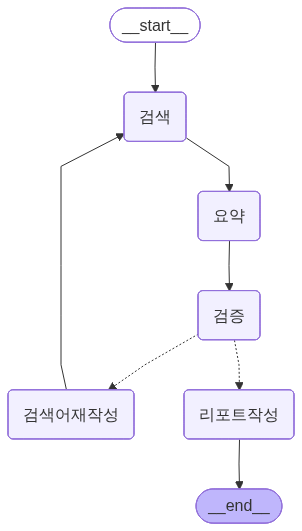

In [25]:
show_graph(app)

## 11. `invoke()`로 전체 실행하기

`invoke()`는 그래프를 끝까지 실행한 뒤 최종 State를 반환한다.  
최종 State의 `report` 필드에 뉴스 브리핑 결과가 들어 있다.

In [26]:
initial_state: SummaryNewsState = {
    "topic": "생성형 AI 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

result = app.invoke(initial_state)

print("\n" + "=" * 70)
print("최종 실행 결과")
print("=" * 70)
print("검색 횟수:", result["search_count"])
print("기사 요약 수:", len(result["summaries"]))
print("검증 결과:", result["feedback"])
print("\n" + result["report"])

  [검색 #1] 검색어: 생성형 AI 교육 트렌드
  [검색] 5개 문서 수집
  [요약] 5개 문서 요약 시작
    - 요약 완료: Students Are Learning Less and Getting Higher Grad
    - 요약 완료: Paul Vallas: How AI can bring the DNA of success t
    - 요약 완료: Code Ninjas: The AI-In-Education Problem Isn’t Che
    - 요약 완료: Opinion: AI and the Employment Outlook for College
    - 요약 완료: Axios Live: AI is rewriting the student career map
  [검증] 유효 요약 5개 → 충분 여부: True
  [결정] 검증 통과 → 리포트작성
  [리포트작성] 최종 리포트 생성

최종 실행 결과
검색 횟수: 1
기사 요약 수: 5
검증 결과: 유효한 기사 요약이 3개 이상이다.

## 뉴스 브리핑: 생성형 AI 교육 트렌드

### 검색 개요
- 검색어: 생성형 AI 교육 트렌드
- 검색 횟수: 1
- 기사 요약 수: 5
- 검증 결과: 유효한 기사 요약이 3개 이상이다.

### 주요 내용
최근 연구에 따르면, AI의 활용이 학생들의 학습 방식에 큰 영향을 미치고 있으며, 성적 향상과 실제 학습 간의 괴리가 발생하고 있다. AI는 맞춤형 학습 자료 제공과 같은 긍정적인 역할을 할 수 있지만, 학생들이 수동적으로 AI에 의존하는 경향이 문제로 지적되고 있다.

### 기사별 요약
1. **Students Are Learning Less and Getting Higher Grades Because of AI, Study Finds**
   - 요약: 학생들이 AI를 활용하는 방식은 보조, 재설정, 대체로 나뉘며, 대체 방식은 성적을 높일 수 있지만 실제 학습과는 관련이 없다. 감독이 없는 과제에서 AI 대체가 적합하다는 점이 강조된다.


## 12. `stream()`으로 노드별 업데이트만 보기

`stream_mode="updates"`는 각 노드가 반환한 업데이트 값만 단계별로 보여준다.  
`event` 전체를 출력하면 노드 이름과 업데이트 데이터가 함께 출력된다.  
업데이트 데이터만 보고 싶으면 `event.values()`에서 값을 꺼낸다.

In [27]:
initial_state: SummaryNewsState = {
    "topic": "AI 반도체 최신 뉴스",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

print("=== 노드별 업데이트 데이터만 출력 ===")

for event in app.stream(initial_state, stream_mode="updates"):
    for update_data in event.values():
        print(update_data.keys())

=== 노드별 업데이트 데이터만 출력 ===
  [검색 #1] 검색어: AI 반도체 최신 뉴스
  [검색] 5개 문서 수집
dict_keys(['search_query', 'search_results', 'search_count'])
  [요약] 5개 문서 요약 시작
    - 요약 완료: FII challenges Broadcom and Nvidia as CPO race shi
    - 요약 완료: The Tech Download: Chip stocks surge in ‘historic’
    - 요약 완료: MCHP Stock Quote Price and Forecast - CNN
    - 요약 완료: Saltware Wins Government-Led AI Transformation Pro
    - 요약 완료: Asia's tech giants give AI bull run a new centre o
dict_keys(['summaries'])
  [검증] 유효 요약 5개 → 충분 여부: True
  [결정] 검증 통과 → 리포트작성
dict_keys(['is_sufficient', 'feedback'])
  [리포트작성] 최종 리포트 생성
dict_keys(['report'])


## 13. `stream()` 결과를 보기 좋게 출력하기

업데이트 전체를 그대로 출력하면 결과가 길어질 수 있다.  
따라서 노드별 핵심 정보만 요약해서 출력하는 방식이 수업에는 더 적합하다.

In [28]:
initial_state: SummaryNewsState = {
    "topic": "로컬 LLM 교육 트렌드",
    "search_query": "",
    "search_results": [],
    "summaries": [],
    "is_sufficient": False,
    "feedback": "",
    "report": "",
    "search_count": 0,
}

print(f"{'단계':<5} {'노드':<12} {'출력 요약'}")
print("-" * 70)

step = 0

for event in app.stream(initial_state, stream_mode="updates"):
    step += 1

    # event는 {"노드명": {"업데이트필드": 값}} 구조이다.
    node_name = list(event.keys())[0]
    output = event[node_name]

    if "search_results" in output:
        summary = f"{len(output['search_results'])}개 문서 수집"
    elif "summaries" in output:
        summary = f"{len(output['summaries'])}개 기사 요약"
    elif "is_sufficient" in output:
        summary = f"충분 여부 = {output['is_sufficient']}, 피드백 = {output['feedback'][:35]}"
    elif "search_query" in output:
        summary = f"새 검색어 = {output['search_query'][:40]}"
    elif "report" in output:
        summary = "최종 리포트 생성"
    else:
        summary = str(output)[:60]

    print(f"{step:<5} {node_name:<12} {summary}")

단계    노드           출력 요약
----------------------------------------------------------------------
  [검색 #1] 검색어: 로컬 LLM 교육 트렌드
  [검색] 5개 문서 수집
1     검색           5개 문서 수집
  [요약] 5개 문서 요약 시작
    - 요약 완료: Boston University International Student Says This 
    - 요약 완료: NY Lawyer Gets A Year After $20M Emigrant Bank Fra
    - 요약 완료: Fenwick Reaches $54M Deal To Exit FTX Litigation -
    - 요약 완료: Tech, Media & Telecom Roundup: Market Talk - WSJ
    - 요약 완료: Arraignment Set For M&A Atty, Others In Insider Tr
2     요약           5개 기사 요약
  [검증] 유효 요약 5개 → 충분 여부: True
  [결정] 검증 통과 → 리포트작성
3     검증           충분 여부 = True, 피드백 = 유효한 기사 요약이 3개 이상이다.
  [리포트작성] 최종 리포트 생성
4     리포트작성        최종 리포트 생성


## 정리

이 단계에서 확인한 내용은 다음과 같다.

1. 검색 결과를 바로 리포트에 넣기보다 기사별 요약으로 중간 처리할 수 있다.
2. 요약 노드를 분리하면 검색 결과의 품질과 최종 리포트의 근거를 더 명확히 관리할 수 있다.
3. 검증 노드는 요약 결과를 기준으로 충분성을 판단한다.
4. 조건부 Edge는 검증 결과에 따라 `리포트작성` 또는 `검색어재작성`으로 이동한다.
5. 재검색 루프에는 최대 검색 횟수 제한이 필요하다.
6. `stream_mode="updates"`와 `event.values()`를 사용하면 노드별 업데이트 데이터만 확인할 수 있다.

07-1부터 07-4까지의 흐름은 다음과 같다.

| 파일 | 핵심 기능 |
|---|---|
| 07-1 | Tavily 검색 노드 만들기 |
| 07-2 | 검색 결과를 리포트로 정리하기 |
| 07-3 | 검증과 재검색 루프 추가하기 |
| 07-4 | 기사별 요약을 추가해 더 근거 있는 뉴스 에이전트 만들기 |

---

## 핵심 정리

```python
# 1. Tavily Search 도구 초기화
from langchain_tavily import TavilySearch

tavily_tool = TavilySearch(
    max_results=5,
    topic="news",
    search_depth="advanced",
    time_range="month",
)

raw_result = tavily_tool.invoke({"query": "검색어"})
results = raw_result["results"]


# 2. State 정의
from typing_extensions import TypedDict

MAX_SEARCH_COUNT = 3  # 최초 검색 1회 + 재검색 최대 2회

class SummaryNewsState(TypedDict):
    topic: str
    search_query: str
    search_results: list[dict]
    summaries: list[dict]
    is_sufficient: bool
    feedback: str
    report: str
    search_count: int


# 3. 검색 노드
def search_node(state: SummaryNewsState) -> dict:
    query = state.get("search_query") or state["topic"]
    search_count = state.get("search_count", 0) + 1

    raw_result = tavily_tool.invoke({"query": query})
    results = normalize_tavily_results(raw_result)

    return {
        "search_query": query,
        "search_results": results,
        "search_count": search_count,
    }


# 4. 기사별 요약 노드
def summarize_node(state: SummaryNewsState) -> dict:
    results = state.get("search_results", [])
    summaries = []

    for item in results:
        title = item.get("title", "제목 없음")
        url = item.get("url", "URL 없음")
        content = item.get("content", "")

        summary = summary_chain.invoke({
            "title": title,
            "url": url,
            "content": content,
        })

        summaries.append({
            "title": title,
            "url": url,
            "summary": summary,
        })

    return {"summaries": summaries}


# 5. 요약 결과 검증 노드
def verify_node(state: SummaryNewsState) -> dict:
    summaries = state.get("summaries", [])

    valid_summaries = [
        item for item in summaries
        if item.get("url") and len(item.get("summary", "")) >= 50
    ]

    is_sufficient = len(valid_summaries) >= 3

    if is_sufficient:
        feedback = "유효한 기사 요약이 3개 이상이다."
    else:
        feedback = f"유효한 기사 요약이 {len(valid_summaries)}개이다. 추가 검색이 필요하다."

    return {
        "is_sufficient": is_sufficient,
        "feedback": feedback,
    }


# 6. 조건부 Edge로 검증 후 분기
def route_after_verify(state: SummaryNewsState) -> str:
    if state["is_sufficient"]:
        return "리포트작성"

    if state.get("search_count", 0) >= MAX_SEARCH_COUNT:
        return "리포트작성"

    return "검색어재작성"


builder.add_conditional_edges(
    "검증",
    route_after_verify,
    {
        "리포트작성": "리포트작성",
        "검색어재작성": "검색어재작성",
    },
)


# 7. 재검색 루프
builder.add_edge("검색어재작성", "검색")
```

- 노드 설명

| 노드 | 역할 |
|---|---|
| 검색 | 현재 검색어로 Tavily Search API를 호출해 최신 뉴스 검색을 수행한다. |
| 요약 | 검색 결과를 LLM으로 기사별 요약으로 변환한다. |
| 검증 | 기사 요약 수, 요약 길이, 출처 URL 기준으로 결과가 충분한지 판단한다. |
| 검색어재작성 | 검색 결과가 부족할 때 LLM으로 새로운 검색어를 생성한다. |
| 리포트작성 | 기사별 요약과 검증 결과를 바탕으로 최종 뉴스 브리핑 리포트를 작성한다. |

- State 필드 설명

| State 필드 | 의미 |
|---|---|
| `topic` | 사용자가 입력한 원래 주제이다. |
| `search_query` | Tavily Search API에 전달되는 현재 검색어이다. |
| `search_results` | Tavily에서 반환한 원본 검색 결과 목록이다. |
| `summaries` | LLM이 생성한 기사별 요약 결과 목록이다. |
| `is_sufficient` | 요약 결과가 최종 리포트 작성에 충분한지 나타내는 값이다. |
| `feedback` | 검증 결과 또는 재검색이 필요한 이유이다. |
| `report` | LLM이 작성한 최종 뉴스 브리핑 리포트이다. |
| `search_count` | 검색 노드가 실행된 횟수이다. |

이 실습은 LangGraph에서 **외부 API 검색, LLM 기사별 요약, 검증, 조건부 분기, 재검색 루프, 최종 리포트 작성**을 하나의 그래프로 구성하는 예제이다.

핵심 흐름은 다음과 같다.

```text
START
  ↓
검색
  ↓
요약
  ↓
검증
  ├─ 충분함 → 리포트작성 → END
  └─ 부족함 → 검색어재작성 → 검색
```

07-3 실습이 `검색 → 검증 → 재검색 → 리포트작성` 구조였다면, 07-4 실습은 여기에 **기사별 요약 노드**를 추가한 확장 구조이다.

이 구조에서 가장 중요한 부분은 다음 세 가지이다.

1. `요약` 노드는 검색 결과를 그대로 사용하지 않고, LLM을 통해 기사별 요약으로 변환한다.
2. `검증` 노드는 요약 결과의 개수와 품질을 기준으로 리포트 작성 가능 여부를 판단한다.
3. 조건부 Edge는 검증 결과에 따라 `리포트작성`으로 갈지, `검색어재작성`으로 갈지 결정한다.

따라서 07-4 실습의 핵심은 단순 검색이 아니라, **검색 결과를 LLM으로 요약하고, 요약 품질을 검증한 뒤, 부족하면 다시 검색하는 Agentic RAG형 워크플로우**를 구성하는 데 있다.